In [9]:
import numpy as np
from pathlib import Path

root_dir = Path(
    # "logs/updateDSO_updateNormalization_IXI075-Guys-0754-T1_2views_20260210_sds0.1_startFrom0_x0+grad_newBound_noNorm/eval/epoch_03000"
    "logs/IXI075-Guys-0754-T1_2views_20260210/eval/epoch_03000"
)
gt_path = root_dir / "image_gt.npy"
pred_path = root_dir / "image_pred.npy"
gt = np.load(gt_path)
pred = np.load(pred_path)
print(gt.shape, pred.shape)
# (256, 256, 173) (256, 256, 173)
print(gt.min(), gt.max(), pred.min(), pred.max())

(256, 256, 173) (256, 256, 173)
-0.016859606 0.57320225 0.0002932101 0.40336642


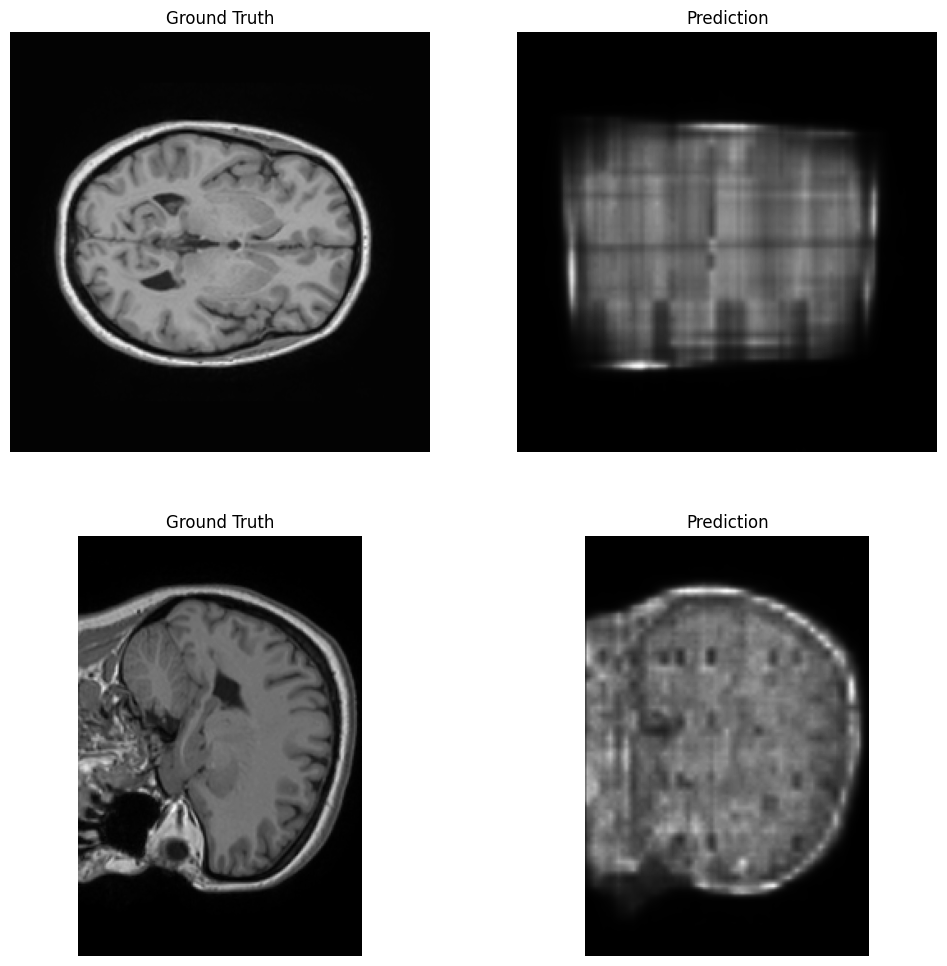

In [10]:
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 12))
plt.subplot(2, 2, 1)
plt.imshow(gt[..., 86], cmap="gray")
plt.title("Ground Truth")
plt.axis("off")
plt.subplot(2, 2, 2)
plt.imshow(pred[..., 86], cmap="gray")
plt.title("Prediction")
plt.axis("off")
# plt.show()
plt.subplot(2, 2, 3)
plt.imshow(gt[150], cmap="gray")
plt.title("Ground Truth")
plt.axis("off")
plt.subplot(2, 2, 4)
plt.imshow(pred[150], cmap="gray")
plt.title("Prediction")
plt.axis("off")
plt.show()

In [ ]:
# conpare 2 pickle
import pickle

with open(
    "/home/czfy/IXI_dataset/IXI_downsampledx4_iacl_SyN/IXI075-Guys-0754/data_2views_updateDSO_updateNormalization.pickle",
    "rb",
) as handle:
    convert = pickle.load(handle)["image"]
with open(
    "/home/czfy/IXI_dataset/IXI_downsampledx4_iacl_SyN/IXI075-Guys-0754/data_2views_updateDSO_updateNormalization_updateNoConvert.pickle",
    "rb",
) as handle:
    no_convert2 = pickle.load(handle)["image"]

print(convert.mean())
print(no_convert2.mean())
print(convert.max())
print(no_convert2.max())

0.13143677
0.13143677
1.4263612
1.4263612


(255, 512, 512)


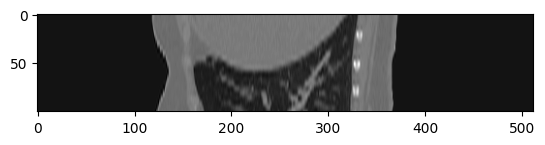

In [ ]:
# sitk vs. nibabel
import SimpleITK as sitk
import nibabel as nib
import matplotlib.pyplot as plt

path = "/home/public/CTSpine1K/data/data-MHD_ctpro_woMask1/volume-covid19-A-0377_ct/ct_file.mha"
sitk_data = sitk.GetArrayFromImage(sitk.ReadImage(path))
print(
    sitk_data.shape,
)

plt.imshow(sitk_data[:100, ..., 200], cmap="gray")
# z,y,x